In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load datasets
calendar = pd.read_csv("../data/calendar.csv")
sell_prices = pd.read_csv("../data/sell_prices.csv")
sales = pd.read_csv("../data/sales_train_validation.csv")

print("Datasets loaded successfully!")
print("Calendar:", calendar.shape)
print("Sell Prices:", sell_prices.shape)
print("Sales:", sales.shape)

Datasets loaded successfully!
Calendar: (1969, 14)
Sell Prices: (6841121, 4)
Sales: (30490, 1919)


In [2]:
# Check Missing Values
print("="*50)
print("MISSING VALUES REPORT")
print("="*50)

print("\nCalendar Missing Values:")
print(calendar.isnull().sum()[calendar.isnull().sum() > 0])

print("\nSell Prices Missing Values:")
print(sell_prices.isnull().sum()[sell_prices.isnull().sum() > 0])

print("\nSales Info Columns Missing Values:")
info_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
print(sales[info_cols].isnull().sum())

print("\nTotal Missing in Sales:", sales.isnull().sum().sum())
print("="*50)

MISSING VALUES REPORT

Calendar Missing Values:
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
dtype: int64

Sell Prices Missing Values:
Series([], dtype: int64)

Sales Info Columns Missing Values:
id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
state_id    0
dtype: int64

Total Missing in Sales: 0


In [3]:
# Fix Calendar Missing Values
calendar['event_name_1'] = calendar['event_name_1'].fillna('No Event')
calendar['event_type_1'] = calendar['event_type_1'].fillna('No Event')
calendar['event_name_2'] = calendar['event_name_2'].fillna('No Event')
calendar['event_type_2'] = calendar['event_type_2'].fillna('No Event')

print("Missing values fixed!")
print("\nCalendar Missing Values after fixing:")
print(calendar.isnull().sum())

# Top Events
print("\nTop 10 Events:")
print(calendar[calendar['event_name_1'] != 'No Event']['event_name_1'].value_counts().head(10))

Missing values fixed!

Calendar Missing Values after fixing:
date            0
wm_yr_wk        0
weekday         0
wday            0
month           0
year            0
d               0
event_name_1    0
event_type_1    0
event_name_2    0
event_type_2    0
snap_CA         0
snap_TX         0
snap_WI         0
dtype: int64

Top 10 Events:
event_name_1
SuperBowl        6
ValentinesDay    6
PresidentsDay    6
LentStart        6
LentWeek2        6
StPatricksDay    6
Purim End        6
Pesach End       6
Mother's day     6
MemorialDay      6
Name: count, dtype: int64


Price Statistics:
count    6.841121e+06
mean     4.410952e+00
std      3.408814e+00
min      1.000000e-02
25%      2.180000e+00
50%      3.470000e+00
75%      5.840000e+00
max      1.073200e+02
Name: sell_price, dtype: float64


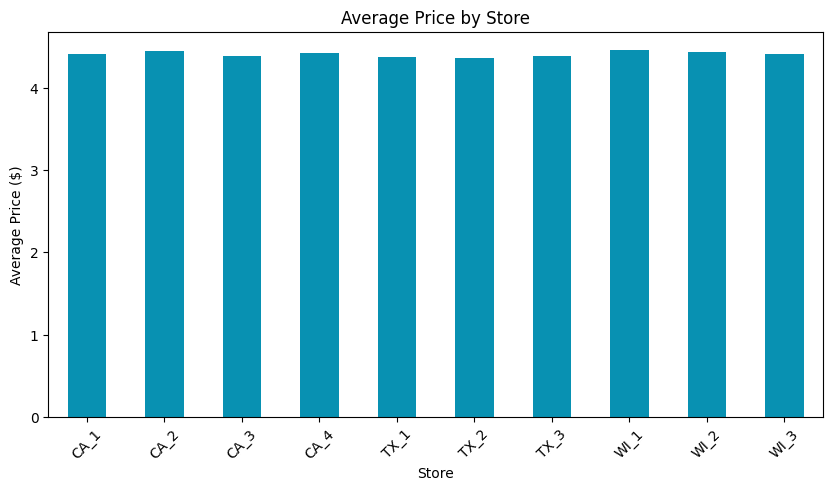

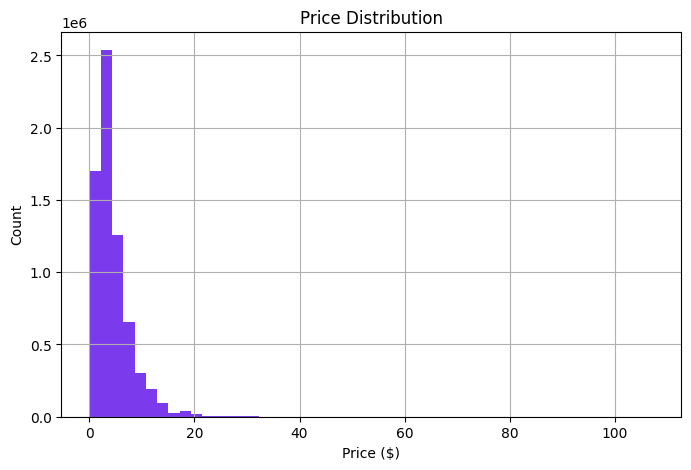


Min Price: $ 0.01
Max Price: $ 107.32
Average Price: $ 4.41
Median Price: $ 3.47


In [4]:
# Price Analysis
print("Price Statistics:")
print(sell_prices['sell_price'].describe())

# Average price by store
plt.figure(figsize=(10,5))
avg_price_store = sell_prices.groupby('store_id')['sell_price'].mean()
avg_price_store.plot(kind='bar', color='#0891B2')
plt.title("Average Price by Store")
plt.xlabel("Store")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=45)
plt.show()

# Price distribution
plt.figure(figsize=(8,5))
sell_prices['sell_price'].hist(bins=50, color='#7C3AED')
plt.title("Price Distribution")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

print("\nMin Price: $", sell_prices['sell_price'].min())
print("Max Price: $", sell_prices['sell_price'].max())
print("Average Price: $", round(sell_prices['sell_price'].mean(), 2))
print("Median Price: $", sell_prices['sell_price'].median())